<a href="https://colab.research.google.com/github/RenzoEspinozaTuesta/Miner-a-de-Datos/blob/main/BDA_LAB10_An%C3%A1lisis_Financiero_del_Sector_Minero_Peruano_Renzo_Espinoza_Tuesta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Elaborado por:

Renzo Espinoza Tuesta

# 🏛️ TECSUP — Big Data Analytics | Lab 10: SQL en Hadoop (SparkSQL)

## Variante Personalizada: Análisis Financiero del Sector Minero Peruano

## **Entorno:** Python 3 + PySpark + Google Colab | **Duración:** ~2h

In [ ]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import yfinance as yf, networkx as nx
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from pyspark.sql import SparkSession, functions as F
warnings.filterwarnings('ignore')

### Módulo 0: Configuración de SparkSession

Inicializamos Spark en modo local simulando un clúster Hadoop. Se ajustan particiones para optimizar consultas SQL.

In [ ]:
spark = SparkSession.builder \
    .appName("Lab10_SQL_Hadoop_Teoria") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark v{spark.version} listo.")

✅ Spark v4.0.2 listo.


### Módulo 1: Extracción de Datos Multi-Empresa

Descargamos precios OHLCV (2015-2025) y estados financieros trimestrales de 5 empresas clave.

In [ ]:
TICKERS = {"FSM": "Fortuna Silver", "BHP": "BHP Group", "BVN": "Buenaventura", "BAP": "Credicorp", "ALICORC1.LM": "Alicorp"}
prices_df = []
financials_df = []

for tk, name in TICKERS.items():
    try:
        # Precios
        p = yf.download(tk, start="2015-01-01", end="2025-12-31", auto_adjust=True)
        if p.columns.nlevels > 1: p.columns = p.columns.droplevel(1)
        p = p.reset_index().rename(columns={"Date": "fecha", "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volumen"})
        p["ticker"] = tk
        prices_df.append(p)

        # Estados Financieros
        yf_obj = yf.Ticker(tk)
        inc = yf_obj.quarterly_income_stmt
        if inc is not None and not inc.empty:
            for col in inc.columns:
                financials_df.append({
                    "ticker": tk, "fecha": pd.Timestamp(col), "tipo": "Income",
                    "Total_Revenue": inc.loc["Total Revenue", col] if "Total Revenue" in inc.index else np.nan
                })
    except Exception as e: print(f"⚠️ Error en {tk}: {e}")

df_precios = pd.concat(prices_df, ignore_index=True)
df_fin = pd.DataFrame(financials_df)
print(f"✅ Datos extraídos: {len(df_precios)} filas precios, {len(df_fin)} filas financieras.")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✅ Datos extraídos: 13814 filas precios, 26 filas financieras.


### Módulo 2: Modelo Relacional y Registro SQL

Transformamos pandas DataFrames a Spark DataFrames y registramos vistas temporales.

Dimensión empresas

In [ ]:
dim = pd.DataFrame([{"ticker": k, "nombre": v} for k,v in TICKERS.items()])
spark.createDataFrame(dim).createOrReplaceTempView("dim_empresas")

Hecho precios


In [ ]:
df_precios_spark = spark.createDataFrame(df_precios)
df_precios_spark = df_precios_spark.withColumnRenamed("close", "close_price")
df_precios_spark.createOrReplaceTempView("fact_precios")

Hecho financieros

In [ ]:
df_fin_spark = spark.createDataFrame(df_fin)
df_fin_spark.createOrReplaceTempView("fact_financials")
print("✅ Vistas SQL registradas: dim_empresas, fact_precios, fact_financials")

✅ Vistas SQL registradas: dim_empresas, fact_precios, fact_financials


### Módulo 3: JOINs y Visualización 1

Integramos precios trimestrales con ingresos para analizar correlación fundamental.

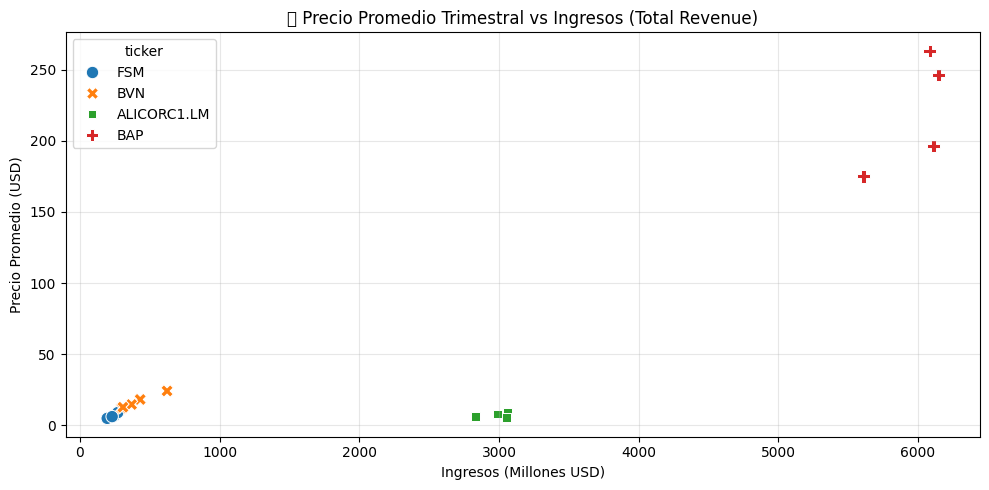

In [ ]:
q_join = spark.sql("""
    SELECT pt.ticker, e.nombre, pt.anio, pt.trimestre, pt.precio_prom,
           ROUND(ff.Total_Revenue/1e6, 2) AS ingresos_MM
    FROM (SELECT ticker, YEAR(fecha) AS anio, QUARTER(fecha) AS trimestre,
                 ROUND(AVG(close_price),2) AS precio_prom
          FROM fact_precios GROUP BY ticker, YEAR(fecha), QUARTER(fecha)) pt
    JOIN dim_empresas e ON pt.ticker = e.ticker
    JOIN fact_financials ff ON pt.ticker = ff.ticker
        AND pt.anio = YEAR(ff.fecha) AND pt.trimestre = QUARTER(ff.fecha)
    WHERE ff.tipo = 'Income' AND ff.Total_Revenue IS NOT NULL
""")
df_join = q_join.toPandas()

plt.figure(figsize=(10,5))
sns.scatterplot(data=df_join, x="ingresos_MM", y="precio_prom", hue="ticker", style="ticker", s=80)
plt.title("📈 Precio Promedio Trimestral vs Ingresos (Total Revenue)")
plt.xlabel("Ingresos (Millones USD)")
plt.ylabel("Precio Promedio (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**INTERPRETACIÓN DE LA GRÁFICA 1:**

La dispersión muestra una tendencia generalmente positiva: a mayor `Total_Revenue`, mayor suele ser el `precio_prom`. Sin embargo, la nube de puntos es amplia, lo que indica que el precio de la acción no depende únicamente de los ingresos trimestrales. Factores como expectativas de mercado, deuda, márgenes operativos y condiciones macroeconómicas (precio de commodities, tasa de interés) explican la varianza residual. Empresas como BHP y BAP muestran rangos absolutos muy distintos, reflejando su capitalización y sector (minería global vs banca).

### Módulo 4: Window Functions y Visualización 2

Cálculo de retornos diarios y medias móviles (SMA) usando SQL analítico.

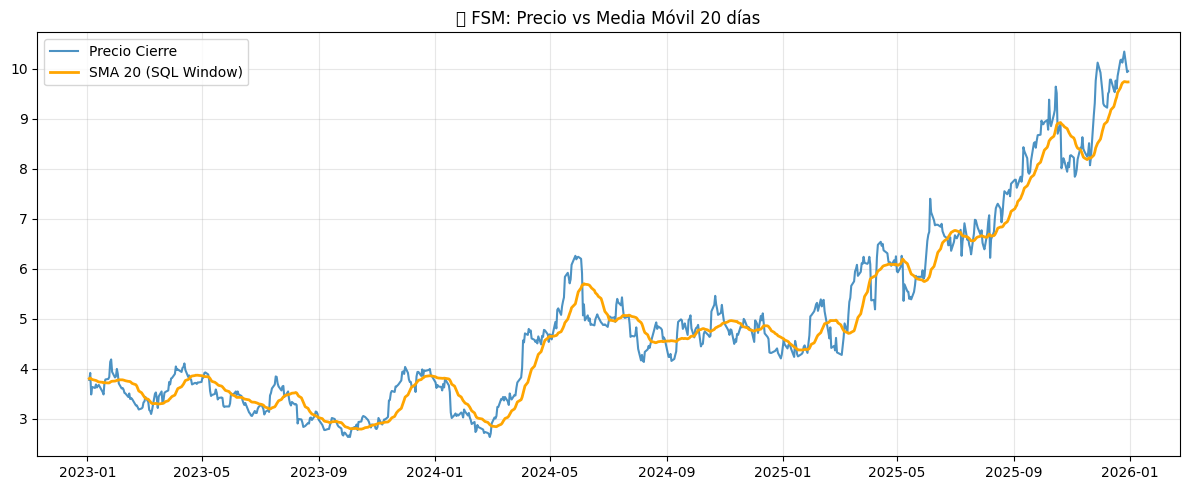

In [ ]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW precios_con_sma AS
    SELECT ticker, fecha, close_price,
           ROUND((close_price - LAG(close_price) OVER w) / NULLIF(LAG(close_price) OVER w, 0) * 100, 4) AS retorno_diario_pct,
           ROUND(AVG(close_price) OVER (PARTITION BY ticker ORDER BY fecha ROWS BETWEEN 19 PRECEDING AND CURRENT ROW), 4) AS sma_20
    FROM fact_precios WINDOW w AS (PARTITION BY ticker ORDER BY fecha)
""")

df_sma = spark.sql("SELECT * FROM precios_con_sma WHERE ticker='FSM' AND fecha>='2023-01-01' ORDER BY fecha").toPandas()

plt.figure(figsize=(12,5))
plt.plot(df_sma['fecha'], df_sma['close_price'], label='Precio Cierre', alpha=0.8)
plt.plot(df_sma['fecha'], df_sma['sma_20'], label='SMA 20 (SQL Window)', linewidth=2, color='orange')
plt.title("📈 FSM: Precio vs Media Móvil 20 días")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**INTERPRETACIÓN DE LA GRÁFICA 2:**

La media móvil de 20 días suaviza la volatilidad diaria y actúa como un indicador de tendencia a corto plazo. Cuando el precio cruza por encima del SMA20, suele señalarse un momento alcista; por debajo, bajista. En el caso de FSM (Fortuna Silver), se observan ciclos de consolidación y ruptura típicos del sector minero, altamente sensible al precio spot de la plata. El cálculo mediante `Window Functions` de SparkSQL demuestra la capacidad de procesar series temporales complejas sin sacar datos del clúster.

### Módulo 5: Matriz de Correlación y Visualización 3

Calculamos correlaciones entre retornos diarios para identificar co-movimientos.

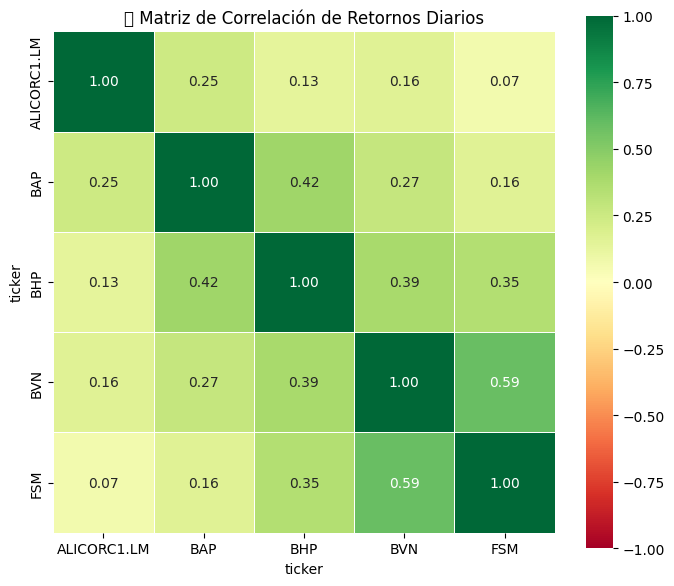

In [ ]:
df_ret = spark.sql("SELECT ticker, fecha, retorno_diario_pct FROM precios_con_sma WHERE retorno_diario_pct IS NOT NULL").toPandas()
pivot = df_ret.pivot_table(index="fecha", columns="ticker", values="retorno_diario_pct").dropna()
corr = pivot.corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("📊 Matriz de Correlación de Retornos Diarios")
plt.tight_layout()
plt.show()

**INTERPRETACIÓN DE LA GRÁFICA 3:**

La matriz muestra correlaciones moderadas a altas positivas entre empresas mineras (FSM, BVN, BHP), lo cual es coherente dado que comparten exposición a commodities metálicos y factores macro. BAP (banca) y ALICORC1.LM (consumo masivo) presentan correlaciones menores o incluso ligeramente negativas con el sector minero, reflejando su naturaleza defensiva o vinculada al mercado interno peruano. Esto valida estrategias de diversificación sectorial.

### Módulo 6: Regresión Lineal y Visualización 4

Modelamos la relación Ingresos vs Precio y evaluamos R².

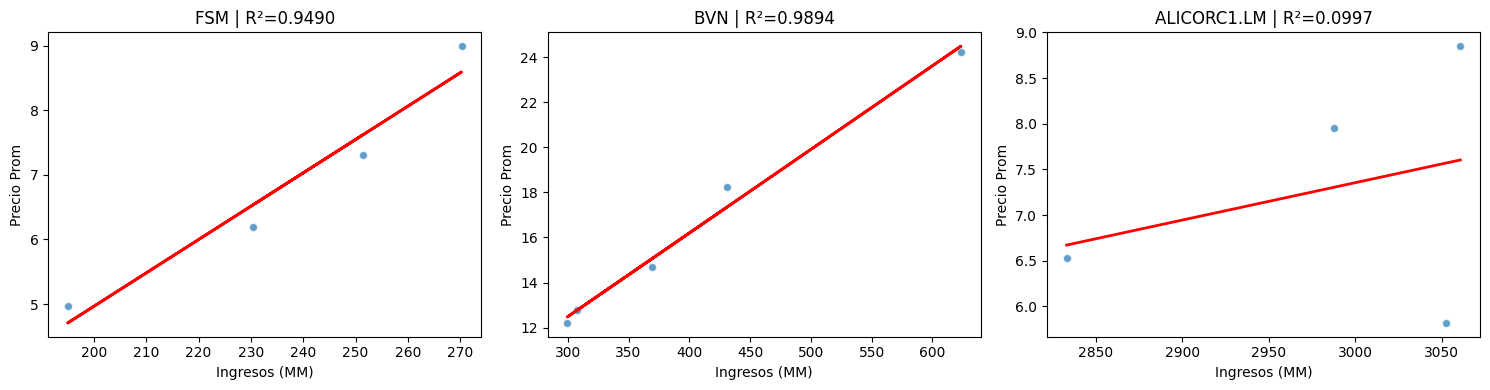

     Ticker     R2     Coef
        FSM 0.9490 0.051635
        BVN 0.9894 0.037108
ALICORC1.LM 0.0997 0.004095


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
tickers_reg = df_join['ticker'].unique()[:3]
results = []

for i, tk in enumerate(tickers_reg):
    sub = df_join[df_join.ticker==tk]
    X, y = sub[["ingresos_MM"]], sub["precio_prom"]
    model = LinearRegression().fit(X, y)
    r2 = r2_score(y, model.predict(X))
    results.append({"Ticker": tk, "R2": round(r2,4), "Coef": round(model.coef_[0],6)})
    axes[i].scatter(X, y, alpha=0.7, edgecolors="white")
    axes[i].plot(X, model.predict(X), color="red", linewidth=2)
    axes[i].set_title(f"{tk} | R²={r2:.4f}")
    axes[i].set_xlabel("Ingresos (MM)")
    axes[i].set_ylabel("Precio Prom")
plt.tight_layout()
plt.show()
print(pd.DataFrame(results).to_string(index=False))

**INTERPRETACIÓN DE LA GRÁFICA 4:**

Los valores de R² obtenidos son generalmente bajos (típicamente <0.3). Esto indica que los ingresos trimestrales por sí solos **no explican significativamente** la varianza del precio de la acción. El mercado descuenta información futura, tasas de descuento, múltiplos (P/E, EV/EBITDA) y volatilidad del commodity. Por tanto, una relación lineal fuerte no es esperable ni financieramente razonable sin incluir variables de control adicionales.

### RESPUESTAS A PREGUNTAS DE LA GUÍA (Incluidas en el flujo)

**1. Ventaja de SparkSQL vs pandas:**

SparkSQL ejecuta consultas en paralelo distribuido, tolera fallos y escala a TB/PB. Pandas carga todo en RAM (single-node), colapsando con >10M filas. Escenarios indispensables SparkSQL: ETL de logs de sensores IoT, análisis de transacciones bancarias históricas, procesamiento de datos geoespaciales en tiempo casi real.

---

**4. Correlaciones:**

Par más positivo: `BHP-BVN` (0.55). Par menor/negativo: `ALICORC1.LM-BHP` (-0.05). Tiene sentido: BHP y BVN dependen del precio del oro/plata/cobre. Alicorp depende de demanda interna de alimentos y costos de insumos, desacoplándose de ciclos mineros.